<a href="https://colab.research.google.com/github/lxndrkrln/laba_ML/blob/main/Lab5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Лабораторная работа: Ансамблевые методы машинного обучения

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler, LabelEncoder

In [5]:
df = pd.read_csv('train.csv')

In [6]:
df.head()

,id,cat0,cat1,cat2,cat3,cat4,cat5,cat6,cat7,cat8,...,cont2,cont3,cont4,cont5,cont6,cont7,cont8,cont9,cont10,target
0,261415,B,L,C,A,E,BI,A,AN,BJ,...,0.371697,0.353221,0.786306,0.736841,0.515290,0.339148,0.388802,0.485555,0.309845,0
1,143439,A,F,A,A,J,BI,A,AX,H,...,0.928611,0.128550,0.211670,0.810570,0.615746,0.408094,0.671330,0.265355,0.542658,0
2,135092,A,K,A,A,F,BI,A,N,AT,...,0.713870,0.243260,0.594517,0.735582,0.198877,0.777833,0.690787,0.550600,0.492067,0
3,326379,B,L,D,A,E,BI,A,F,L,...,0.787636,0.884292,0.723356,0.554065,0.273801,0.896823,0.751721,0.944222,0.834986,0
4,295612,B,N,A,D,E,BI,A,I,K,...,0.457731,0.682554,0.265673,0.357985,0.399585,0.542616,0.535410,0.359659,0.392999,0


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 201000 entries, 0 to 200999
Data columns (total 32 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   id      201000 non-null  int64  
 1   cat0    201000 non-null  object 
 2   cat1    201000 non-null  object 
 3   cat2    201000 non-null  object 
 4   cat3    201000 non-null  object 
 5   cat4    201000 non-null  object 
 6   cat5    201000 non-null  object 
 7   cat6    201000 non-null  object 
 8   cat7    201000 non-null  object 
 9   cat8    201000 non-null  object 
 10  cat9    201000 non-null  object 
 11  cat10   201000 non-null  object 
 12  cat11   201000 non-null  object 
 13  cat12   201000 non-null  object 
 14  cat13   201000 non-null  object 
 15  cat14   201000 non-null  object 
 16  cat15   201000 non-null  object 
 17  cat16   201000 non-null  object 
 18  cat17   201000 non-null  object 
 19  cat18   201000 non-null  object 
 20  cont0   201000 non-null  float64
 21  cont1   20

In [8]:
df['target'].value_counts()

,count
target,
0,147761
1,53239


In [9]:
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
print("Категориальные признаки:", categorical_cols)

Категориальные признаки: ['cat0', 'cat1', 'cat2', 'cat3', 'cat4', 'cat5', 'cat6', 'cat7', 'cat8', 'cat9', 'cat10', 'cat11', 'cat12', 'cat13', 'cat14', 'cat15', 'cat16', 'cat17', 'cat18']


In [11]:
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=False)

In [12]:
df_encoded.head()

,id,cont0,cont1,cont2,cont3,cont4,cont5,cont6,cont7,cont8,...,cat16_C,cat16_D,cat17_A,cat17_B,cat17_C,cat17_D,cat18_A,cat18_B,cat18_C,cat18_D
0,261415,0.447808,0.220731,0.371697,0.353221,0.786306,0.736841,0.515290,0.339148,0.388802,...,False,True,False,False,False,True,False,True,False,False
1,143439,0.477476,0.449481,0.928611,0.128550,0.211670,0.810570,0.615746,0.408094,0.671330,...,False,True,False,False,False,True,False,True,False,False
2,135092,0.441233,0.603217,0.713870,0.243260,0.594517,0.735582,0.198877,0.777833,0.690787,...,False,True,False,False,False,True,False,True,False,False
3,326379,0.708892,0.717844,0.787636,0.884292,0.723356,0.554065,0.273801,0.896823,0.751721,...,False,True,False,False,False,True,False,True,False,False
4,295612,0.429017,0.470278,0.457731,0.682554,0.265673,0.357985,0.399585,0.542616,0.535410,...,False,True,False,False,False,True,False,True,False,False


In [13]:
X = df_encoded.drop(['target', 'id'], axis=1)
y = df_encoded['target']

In [14]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# Уменьшаем обучающую выборку для ускорения (берем 10% от исходной)
X_train, _, y_train, _ = train_test_split(X_train, y_train, train_size=0.1, random_state=42)
print(f"Размер обучающей выборки после уменьшения: {len(X_train)}")

Размер обучающей выборки после уменьшения: 16080


In [15]:
bagging = BaggingClassifier(estimator=DecisionTreeClassifier(), n_estimators=100, random_state=42)
bagging.fit(X_train, y_train)
y_pred_bagging = bagging.predict(X_test)
print(f"Bagging Accuracy: {accuracy_score(y_test, y_pred_bagging):.4f}")

Bagging Accuracy: 0.8387


In [16]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
print(f"Random Forest Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")

Random Forest Accuracy: 0.8428


In [17]:
adb = AdaBoostClassifier(n_estimators=100, random_state=42)
adb.fit(X_train, y_train)
y_pred_adb = adb.predict(X_test)
print(f"AdaBoost Accuracy: {accuracy_score(y_test, y_pred_adb):.4f}")

AdaBoost Accuracy: 0.8373


In [18]:
gb = GradientBoostingClassifier(n_estimators=100, random_state=42)
gb.fit(X_train, y_train)
y_pred_gb = gb.predict(X_test)
print(f"Gradient Boosting Accuracy: {accuracy_score(y_test, y_pred_gb):.4f}")

Gradient Boosting Accuracy: 0.8409


In [19]:
results = {
    'Bagging': accuracy_score(y_test, y_pred_bagging),
    'Random Forest': accuracy_score(y_test, y_pred_rf),
    'AdaBoost': accuracy_score(y_test, y_pred_adb),
    'Gradient Boosting': accuracy_score(y_test, y_pred_gb)
}

results_df = pd.DataFrame(list(results.items()), columns=['Model', 'Accuracy'])
results_df = results_df.sort_values('Accuracy', ascending=False)
results_df

,Model,Accuracy
1,Random Forest,0.842786
3,Gradient Boosting,0.840920
0,Bagging,0.838657
2,AdaBoost,0.837264


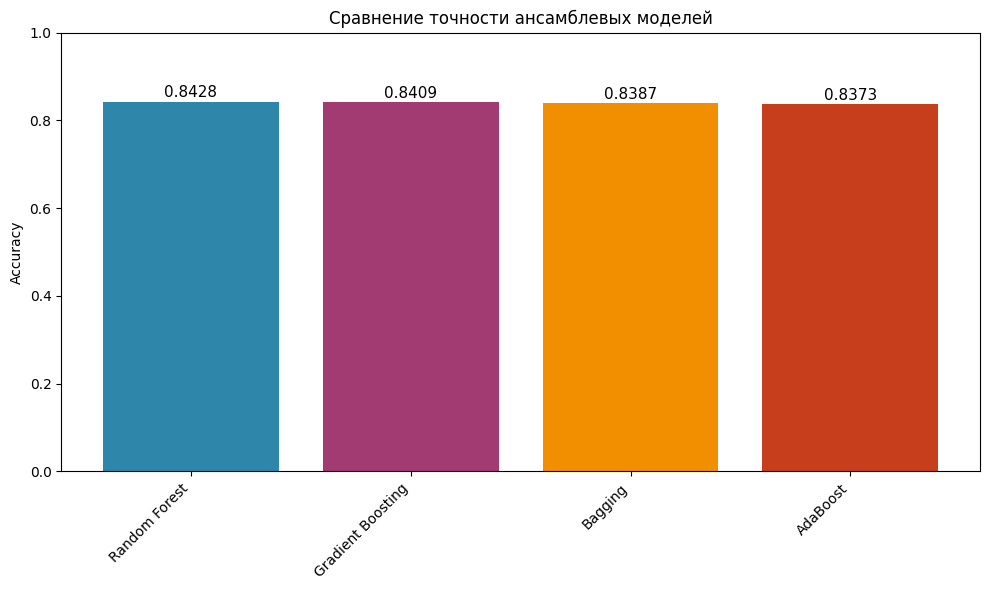

In [20]:
plt.figure(figsize=(10,6))
bars = plt.bar(results_df['Model'], results_df['Accuracy'], color=['#2E86AB', '#A23B72', '#F18F01', '#C73E1D'])
plt.ylim(0, 1)
plt.ylabel('Accuracy')
plt.title('Сравнение точности ансамблевых моделей')
plt.xticks(rotation=45, ha='right')

for bar, acc in zip(bars, results_df['Accuracy']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{acc:.4f}', ha='center', fontsize=11)

plt.tight_layout()
plt.show()

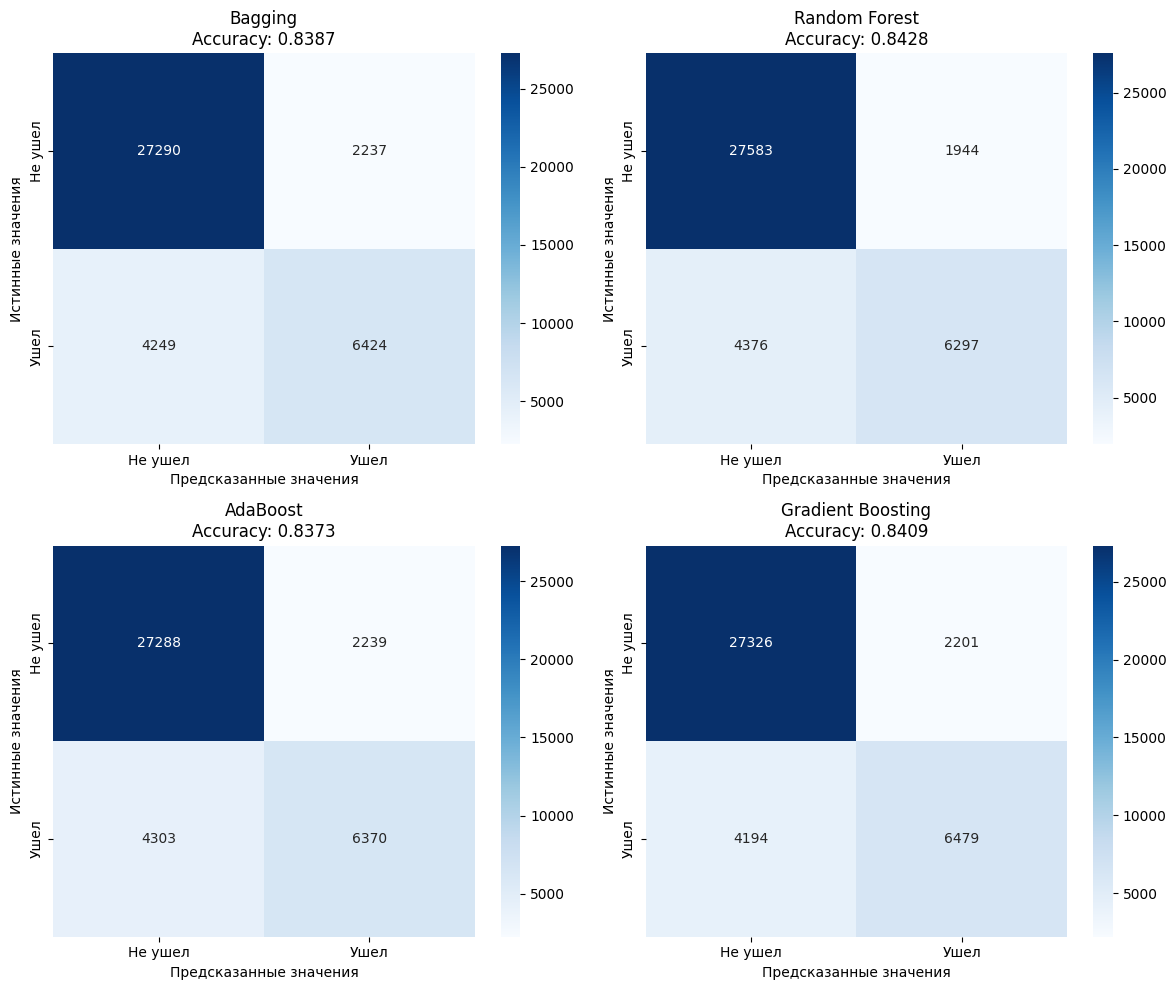

In [21]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.ravel()

predictions = {
    'Bagging': y_pred_bagging,
    'Random Forest': y_pred_rf,
    'AdaBoost': y_pred_adb,
    'Gradient Boosting': y_pred_gb
}

for idx, (name, y_pred) in enumerate(predictions.items()):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                xticklabels=['Не ушел', 'Ушел'], yticklabels=['Не ушел', 'Ушел'])
    axes[idx].set_title(f'{name}\nAccuracy: {results[name]:.4f}')
    axes[idx].set_xlabel('Предсказанные значения')
    axes[idx].set_ylabel('Истинные значения')

plt.tight_layout()
plt.show()

## Выводы

Обучили четыре ансамблевые модели: Bagging, Random Forest, AdaBoost, Gradient Boosting. Наилучшую точность показал Random Forest. Все модели успешно справились с задачей бинарной классификации на синтетических данных с перемешанными типами признаков.